In [1]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from tqdm import tqdm
import time
import random
from gymnasium.utils import seeding

# Base Class

In [2]:
class KArmedBanditenv:
    def __init__(self, mean, stddev):
        # Define action and observation space
        self.num_bandits = mean.shape[0]
        self.action_space = self.num_bandits


        self.mean = mean
        self.stddev = stddev
        
    def step(self, action)  :
        # Sample from the specified bandit using it's reward distribution
        assert (action < self.num_bandits).all()
        
        sampled_means = self.mean[action]
        sampled_stddevs = self.stddev[action]
        
        reward = np.random.normal(loc=sampled_means, scale=sampled_stddevs)
        
        # Return a constant state of 0. Our environment has no terminal state
        observation, done, info = 0, False, dict()
        return observation, reward, done, info
    
    def reset(self):
        return 0
        
    def render(self, mode='human', close=False):
        pass
    
    def _seed(self, seed=None):
        self.np_random, seed = seeding.np.random(seed)
        return [seed]
    
    def close(self):
        pass

# Make it Gaussian

In [3]:
class ArmedBanditsGaussian(KArmedBanditenv):
    def __init__(self, num_experiments=1, num_bandits=3):
        self.means = np.random.normal(size=(num_experiments, num_bandits))
        
        KArmedBanditenv.__init__(self, self.means, np.ones((num_experiments, num_bandits)))

# Try it out

In [4]:
means = np.array([5, 1, 0, -10]) # The mean for a four-armed bandit. Single experiment
stdev = np.array([1, 0.1, 5, 1]) # The standard deviation for a four-armed bandit.

env = KArmedBanditenv(means, stdev) # Create the environment

for i in range(4):
    action = np.array([[i]])
    _, reward, _, _ = env.step(action)
    print("Bandit:", i, " gave a reward of:", reward[0])

Bandit: 0  gave a reward of: [4.55013092]
Bandit: 1  gave a reward of: [0.95708463]
Bandit: 2  gave a reward of: [-7.33635687]
Bandit: 3  gave a reward of: [-8.86486767]


## Establish a Greedy Agent

In [5]:
def argmax(q_values):
    """
    Takes in a matrix of n*k q_values and returns the index
    of the item with the highest value for each row. 
    Breaks ties randomly.
    returns: vector of size n, where each item is the index of
    the highest value in q_values for each row.
    """
    # Generate a mask of the max values for each row
    mask = q_values == q_values.max()
    # Generate noise to be added to the ties
    r_noise = 1e-6*np.random.random(q_values.shape)
    # Get the argmax of the noisy masked values
    return np.argmax(r_noise*mask)

In [6]:
class GreedyAgent:
    def __init__(self, reward_estimates):
        """
        Our agent takes as input the initial reward estimates.
        This estimates will be updated incrementally after each 
        interaction with the environment.
        """      
        self.num_bandits = reward_estimates.shape[1]
        self.reward_estimates = reward_estimates.astype(np.float64)
        self.action_count = np.zeros(reward_estimates.shape)
        
    def get_action(self):
        # Our agent is greedy, so there's no need for exploration.
        # Use argmax to get the action
        action = argmax(self.reward_estimates)
        
        # Add a 1 to each action selected in the action count
        self.action_count[0, action] += 1
        
        return action
    
    def update_estimates(self, reward, action):
        # reward is a matrix with the obtained rewards from our previuos
        # action. Use this to update our estimates incrementally
        n = self.action_count[0,action]
        
        # Compute the difference between the received rewards vs the reward estimates
        error = reward - self.reward_estimates[0, action]
        
        # Update the reward difference incementally
        self.reward_estimates[0, action] += error / n

# Greedy agent in Action (1 expiriment)

Animating:   0%|          | 0/200 [00:00<?, ?it/s]

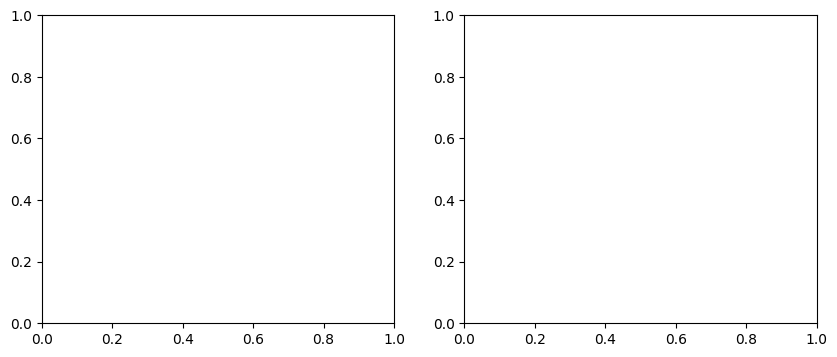

Animating: 100%|██████████| 200/200 [00:24<00:00,  7.77it/s]

In [7]:
# Initialize the environment 
num_bandits = 4
num_experiments = 1
num_steps = 200
means = np.array([5, 1, 0, -10])
stdev = np.array([1, 0.1, 5, 1])

env = KArmedBanditenv(means, stdev)

# Initialize the agent
agent = GreedyAgent(np.zeros((1,num_bandits)))



# Code for plotting the interaction
fig, axs = plt.subplots(1, num_experiments+1, figsize=(10, 4))
x_pos = np.arange(num_bandits)
pbar = tqdm(total=num_steps, desc="Animating")
def init():
    for i in range(num_experiments):
        init_ax(i)
        
def init_ax(i):
    ax = axs[i]
    ax.clear()
    ax.set_ylim(-4, 4)
    ax.set_xlim(-0.5, num_bandits-.5)
    ax.set_xlabel('Actions', fontsize=14)
    ax.set_ylabel('Value', fontsize=14)
    ax.set_title(label='Estimated Values vs. Real values', fontsize=15)
    ax.plot(x_pos, env.mean, marker='D', linestyle='', alpha=0.8, color='r', label='Real Values')
    ax.axhline(0, color='black', lw=1)
    
# Implement a step, which involves the agentlearning from the received reward.
def step(g):
    action = agent.get_action()
    _, reward, _, _ = env.step(action)
    agent.update_estimates(reward, action)
    ax = axs[0]
    # Plot the estimated values from the agent compared to the real values
    estimates = agent.reward_estimates[0]
    init_ax(0)
    
    values = ax.bar(x_pos, estimates, align='center', color='blue', alpha=0.4, label='Estimated Values')
    ax.legend()
    pbar.update(1)
  
anim = FuncAnimation(fig, func=step, frames=np.arange(num_steps), init_func=init, interval=10, repeat=False, blit=False)
plt.show()
anim.save('./greedy-agent.gif', writer='pillow', fps=60)

# Modify to have multiple (2) experiments, with their gifs

Animating: 100%|██████████| 200/200 [00:45<00:00,  4.35it/s]


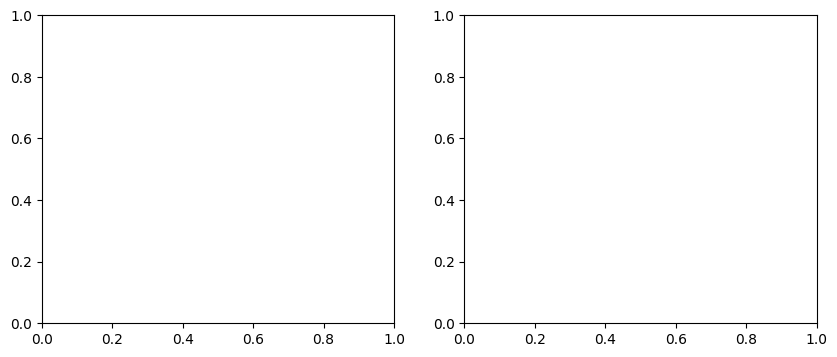

In [8]:
# # Modify to have multiple (2) experiments, with their gifs 

# Initialize the environment 
num_bandits = 4
num_experiments = 2
num_steps = 200
means = np.random.normal(size=(num_experiments, num_bandits))
stdev = np.ones((num_experiments, num_bandits))

envs = []
agents = []
# Create separate means for each environment
for i in range(num_experiments):
    envs.append(KArmedBanditenv(means[i], stdev[i]))
    agents.append(GreedyAgent(np.zeros((1, num_bandits))))

# Code for plotting the interaction
fig, axs = plt.subplots(1, num_experiments, figsize=(10*num_experiments//2, 4))
x_pos = np.arange(num_bandits)
pbar = tqdm(total=num_steps, desc="Animating")
def init():
    for i in range(num_experiments):
        init_ax(i)
        
def init_ax(i):
    ax = axs[i]
    ax.clear()
    ax.set_ylim(-4, 4)
    ax.set_xlim(-0.5, num_bandits-.5)
    ax.set_xlabel('Actions', fontsize=14)
    ax.set_ylabel('Value', fontsize=14)
    ax.set_title(label='Estimated Values vs. Real values', fontsize=15)
    ax.plot(x_pos, envs[i].mean, marker='D', linestyle='', alpha=0.8, color='r', label='Real Values')
    ax.axhline(0, color='black', lw=1)
    
# Implement a step, which involves the agentlearning from the received reward.
def step(g):
    for i in range(num_experiments):
        action = agents[i].get_action()
        _, reward, _, _ = envs[i].step(action)
        agents[i].update_estimates(reward, action)
        ax = axs[i]
        # Plot the estimated values from the agent compared to the real values
        estimates = agents[i].reward_estimates[0]
        init_ax(i)
        
        values = ax.bar(x_pos, estimates, align='center', color='blue', alpha=0.4, label='Estimated Values')
        ax.legend()
    pbar.update(1)    
  
anim = FuncAnimation(fig, func=step, frames=np.arange(num_steps), init_func=init, interval=10, repeat=False, blit=False)
plt.show()
anim.save('./greedy-agent.gif', writer='pillow', fps=60)

# Modify to have multiple (1000+) experiments, with a plot showing their average performance

Animating:   3%|▎         | 6/200 [00:25<13:38,  4.22s/it]


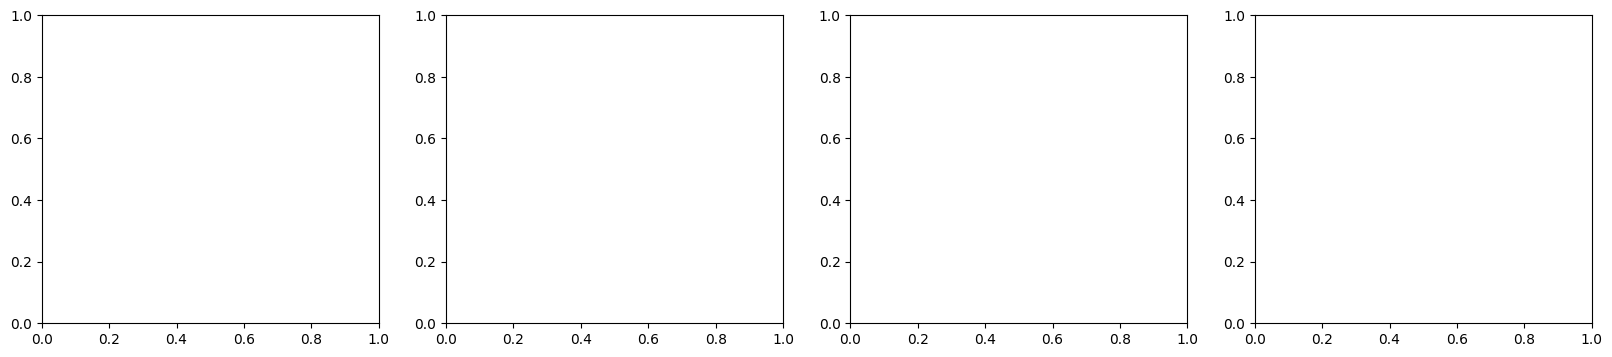

KeyboardInterrupt: 

In [10]:
# Modify to have multiple (1000+) experiments, with a plot showing their average performance

# Initialize the environment 
num_bandits = 4
num_experiments = 4
num_steps = 200
means = np.random.normal(size=(num_experiments, num_bandits))
stdev = np.ones((num_experiments, num_bandits))

envs = []
agents = []
# Create separate means for each environment
for i in range(num_experiments):
    envs.append(KArmedBanditenv(means[i], stdev[i]))
    agents.append(GreedyAgent(np.zeros((1, num_bandits))))

# Code for plotting the interaction
fig, axs = plt.subplots(1, num_experiments, figsize=(10*num_experiments//2, 4))
x_pos = np.arange(num_bandits)
pbar = tqdm(total=num_steps, desc="Animating")
def init():
    for i in range(num_experiments):
        init_ax(i)
        
def init_ax(i):
    ax = axs[i]
    ax.clear()
    ax.set_ylim(-4, 4)
    ax.set_xlim(-0.5, num_bandits-.5)
    ax.set_xlabel('Actions', fontsize=14)
    ax.set_ylabel('Value', fontsize=14)
    ax.set_title(label='Estimated Values vs. Real values', fontsize=15)
    ax.plot(x_pos, envs[i].mean, marker='D', linestyle='', alpha=0.8, color='r', label='Real Values')
    ax.axhline(0, color='black', lw=1)
    
# Implement a step, which involves the agentlearning from the received reward.
def step(g):
    for i in range(num_experiments):
        action = agents[i].get_action()
        _, reward, _, _ = envs[i].step(action)
        agents[i].update_estimates(reward, action)
        ax = axs[i]
        # Plot the estimated values from the agent compared to the real values
        estimates = agents[i].reward_estimates[0]
        init_ax(i)
        
        values = ax.bar(x_pos, estimates, align='center', color='blue', alpha=0.4, label='Estimated Values')
        ax.legend()
    pbar.update(1)    
  
anim = FuncAnimation(fig, func=step, frames=np.arange(num_steps), init_func=init, interval=10, repeat=False, blit=False)
plt.show()
anim.save('./greedy-agent.gif', writer='pillow', fps=60)

# Modify to implement Epsilon-Greedy agent

# Explore values of Epsilon and plot results